In [1]:
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib_map_utils.core.north_arrow import north_arrow
from matplotlib_map_utils import scale_bar
from matplotlib_map_utils import inset_map

import rioxarray as rxr
import numpy as np

## Inspecting the Dutch Municipalities GeoDataFrame

In [2]:
data_folder = '../data/'
fiona.listlayers(f'{data_folder}/vectors/nederland_admin_areas.gpkg')

['country', 'provinces', 'cities']

In [3]:
cities = gpd.read_file(f'{data_folder}/vectors/nederland_admin_areas.gpkg', layer='cities')
cities.shape

(342, 6)

In [4]:
cities.head(1)

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
0,GM0263,Maasdriel,0263,25,Gelderland,"MULTIPOLYGON (((146637.319 416737.822, 146600 ..."


## Filtering the Enschede Municipality

In [5]:
enschede = cities[cities['naam']=='Enschede']
enschede.shape

(1, 6)

In [6]:
enschede.head(1)

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
82,GM0153,Enschede,0153,23,Overijssel,"MULTIPOLYGON (((252038.609 465222.168, 252036...."


## Inspecting the Netherlands National Boundary GeoDataFrame

In [7]:
nederland = gpd.read_file(f'{data_folder}/vectors/nederland_admin_areas.gpkg', layer='country')
nederland.shape

(1, 4)

In [8]:
nederland.head(1)

,identificatie,naam,code,geometry
0,LND6030,Nederland,6030,"MULTIPOLYGON (((118964.59 380422.53, 118977.99..."


## Creating the Enschede Sentinel Subset
### Loading the Full Sentinel Raster for Enschede

In [9]:
enschede_sentinel = rxr.open_rasterio('../data/rasters/enschede_sentinel.tif')
enschede_sentinel.coords

Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 91kB 1.887e+05 1.887e+05 ... 3.019e+05 3.019e+05
  * y            (y) float64 91kB 4.808e+05 4.808e+05 ... 3.675e+05 3.674e+05
    spatial_ref  int64 8B 0

In [10]:
print(enschede_sentinel.rio.crs)

EPSG:28992


### Clipping the Raster

In [11]:
print(enschede_sentinel.rio.crs)
print(enschede.crs)

EPSG:28992
EPSG:28992


In [12]:
enschede_raster = enschede_sentinel.rio.clip(enschede.geometry.values, crs=enschede.crs, drop=True)
enschede_raster.coords

Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 12kB 2.485e+05 2.486e+05 ... 2.639e+05 2.639e+05
  * y            (y) float64 11kB 4.786e+05 4.786e+05 ... 4.648e+05 4.647e+05
    spatial_ref  int64 8B 0

In [13]:
enschede_sentinel.rio.nodata

np.uint16(0)

### Adding NoData Value

In [14]:
enschede_raster = enschede_raster.where(enschede_raster != 0)

### Visualising the Subset

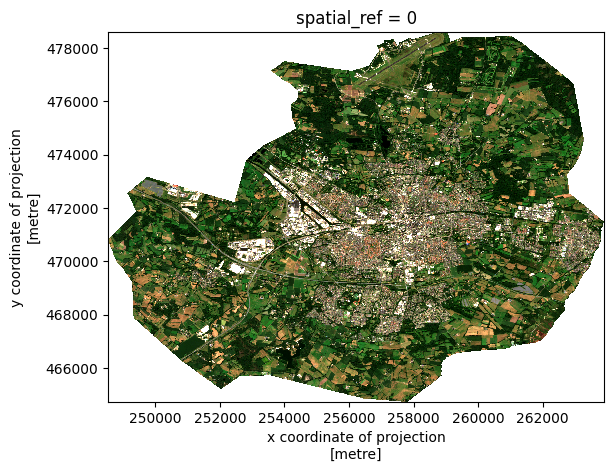

In [15]:
enschede_raster.plot.imshow(robust=True)

## Creating the Enschede Map

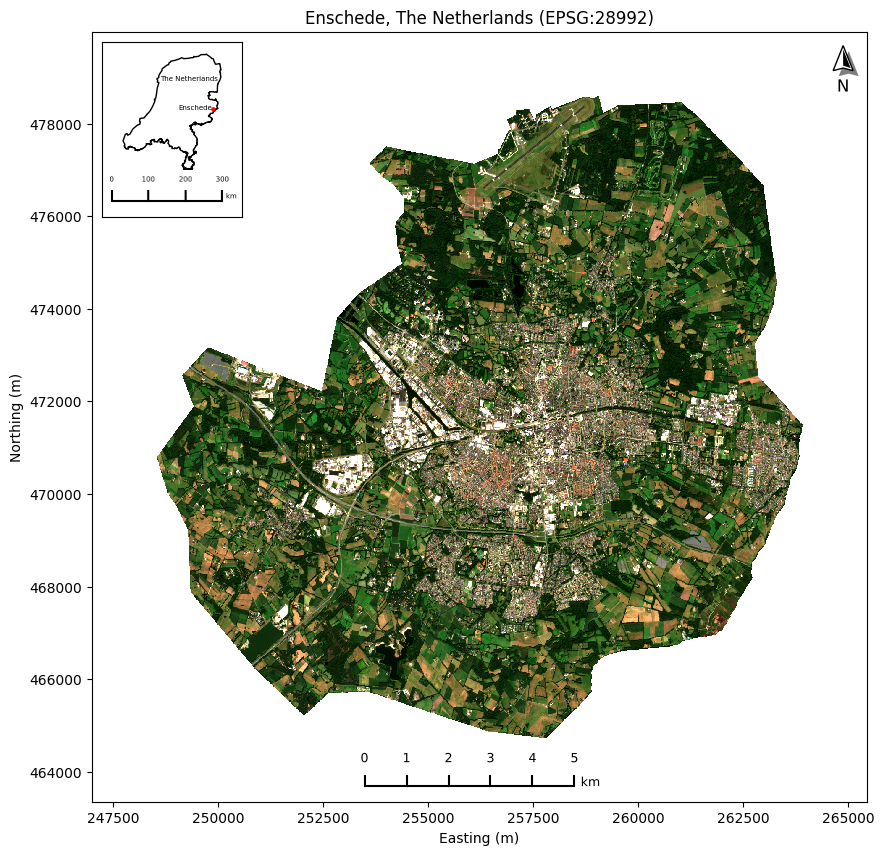

In [16]:
fig, ax = plt.subplots(figsize=(10,10))

enschede_raster.plot.imshow(ax=ax, robust=True)

xlim = ax.get_xlim()
ylim = ax.get_ylim()
x_centre = sum(xlim) / 2
y_centre = sum(ylim) / 2
x_range = (xlim[1] - xlim[0]) * 1.20 / 2
y_range = (ylim[1] - ylim[0]) * 1.20 / 2

ax.set_xlim(x_centre - x_range, x_centre + x_range)
ax.set_ylim(y_centre - y_range, y_centre + y_range)

north_arrow(ax=ax, location='upper right', rotation={'degrees': 0}, scale=0.25, label={'fontsize': 12})
scale_bar(ax=ax, location='lower center', style='ticks', bar={'projection': enschede.crs}, text={'fontsize': 9})

inset = inset_map(ax=ax, location='upper left', size=1.75, pad=0.1, xticks=[], yticks=[])

nederland.plot(ax=inset, color='none')
inset.annotate(xy=(nederland.geometry.centroid.x.iloc[0] + 2.5 * 10**4, nederland.geometry.centroid.y.iloc[0] + 7 * 10**4), text='The Netherlands', ha='center', fontsize=5)

enschede_centroid = enschede.geometry.centroid
enschede_centroid.plot(ax=inset, marker='o', color='red', markersize=5)
inset.annotate(xy=(enschede_centroid.x.iloc[0] - 5 * 10**4, enschede_centroid.y.iloc[0]), text='Enschede', ha='center', fontsize=5)

xlim = inset.get_xlim()
ylim = inset.get_ylim()
x_centre = sum(xlim) / 2
y_centre = sum(ylim) / 2
x_range = (xlim[1] - xlim[0]) * 1.3 / 2
y_range = (xlim[1] - xlim[0]) * 1.3 / 2

inset.set_xlim(x_centre - x_range, x_centre + x_range)
inset.set_ylim(y_centre - y_range * 1.5, y_centre + y_range)

scale_bar(ax=inset, location='lower center', style='ticks', bar={'projection': nederland.crs, 'length': 0.75, 'minor_div': 1}, text={'fontsize': 5})

ax.set_title(f'Enschede, The Netherlands ({enschede.crs})')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()